In [1]:
import matplotlib.pyplot as plt
from src.process_data import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import MultipleLocator

In [ ]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 2

df_all_2d = pd.read_csv(f"../Data/{type_perc}_percolation/all_data_{dim}D.dat", sep='\t')
df_all_2d

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,...,pt_erro,nt_mean,nt_erro,perc_rate,perc_ci_low,perc_ci_high,pt_mean_uncond,pt_erro_uncond,nt_mean_uncond,nt_erro_uncond
0,bond,3,2,2000,200,0.0001,0.003,0.4,1,22,...,0.0028163148218908,194.3612646286452,1.1795640335640498,0.227273,1.012289e-01,0.434404,0.206448,0.081162,44.173015,17.367484
1,bond,3,2,2000,200,0.0001,0.003,0.4,2,22,...,Null,Null,Null,0.000000,1.387779e-17,0.148660,0.000000,0.000000,0.000000,0.000000
2,bond,3,2,2000,200,0.0001,0.003,0.4,3,22,...,Null,Null,Null,0.000000,1.387779e-17,0.148660,0.000000,0.000000,0.000000,0.000000
3,bond,3,2,2000,200,0.0001,0.003,0.5,1,20,...,0.0026084823837827,191.88792206829456,2.0292766851928925,1.000000,8.388699e-01,1.000000,0.916450,0.002608,191.887922,2.029277
4,bond,3,2,2000,200,0.0001,0.003,0.5,2,20,...,0.0014783806273907,192.42416783378337,2.841732837035604,0.600000,3.865779e-01,0.781196,0.549305,0.100293,115.454501,21.147858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,bond,3,2,2000,200,0.0001,0.330,0.8,2,20,...,Null,Null,Null,0.000000,0.000000e+00,0.161130,0.000000,0.000000,0.000000,0.000000
296,bond,3,2,2000,200,0.0001,0.330,0.8,3,20,...,Null,Null,Null,0.000000,0.000000e+00,0.161130,0.000000,0.000000,0.000000,0.000000
297,bond,3,2,2000,200,0.0001,0.330,1.0,1,100,...,Null,Null,Null,0.000000,0.000000e+00,0.036995,0.000000,0.000000,0.000000,0.000000
298,bond,3,2,2000,200,0.0001,0.330,1.0,2,100,...,Null,Null,Null,0.000000,0.000000e+00,0.036995,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_clean_2d = df_all_2d[df_all_2d[["pt_mean", "nt_mean"]].notna().all(axis=1)]
df_clean_2d.loc[:, "rho":"nt_erro"].sort_values(by=["rho", "p0"])

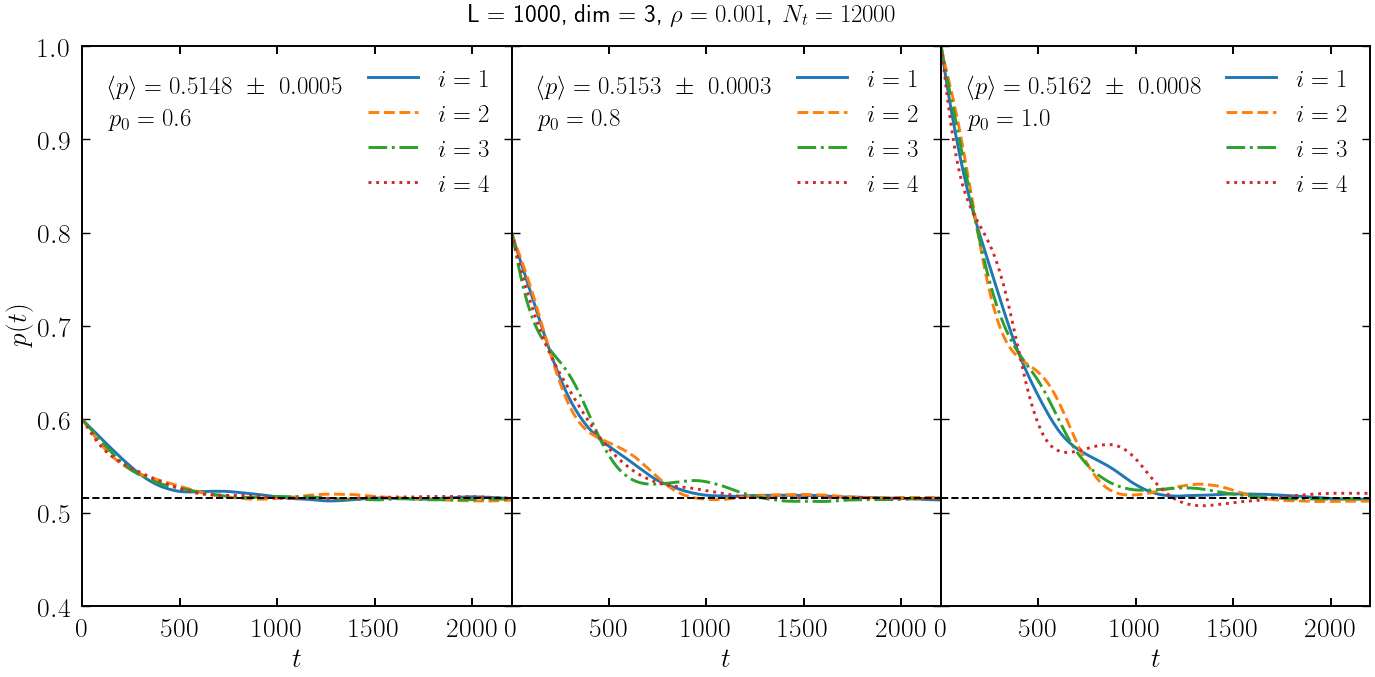

Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):
p0=0.6 | n_curves=4 | mean=0.514842 ± 0.000521 (IC95%: 0.513867–0.515817)
p0=0.8 | n_curves=4 | mean=0.515304 ± 0.000313 (IC95%: 0.514718–0.515890)
p0=1.0 | n_curves=4 | mean=0.516171 ± 0.000842 (IC95%: 0.514601–0.517675)


In [ ]:
# ---------- seus parâmetros ----------
type_perc = "bond"
num_colors = 4
dim = 3
L = 1000
NT = 12000
k=1.0e-08
rho=1.0e-03
p0_lst = [0.6, 0.8, 1.0]
seed_name = [14574188, 344587444, 198323458]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharex=True, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0, 'hspace': 0}  # cola os subplots
)

results = []
rng = np.random.default_rng(12345)

count = 0
linestyles = ['solid', 'dashed', 'dashdot', "dotted", 'None']
#linestyles = ['solid', 'solid', 'solid', 'solid']
for index, ax in enumerate(axes):
    p0 = p0_lst[index]
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed_name[index])
    
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"p_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.5*thickness)

    ax.set_xlabel("$t$")
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.set_xlim([0, max(data["t"])])
    ax.set_ylim([0.4, 1.0])

    means_per_curve = []
    for i in range(1, num_colors+1):
        mi = tail_mean(data[f"p_{i}"], tail_frac=tail_frac)
        if np.isfinite(mi):
            means_per_curve.append(mi)

    mean_pt, se_pt, (lo_pt, hi_pt) = bootstrap_mean_scalar(means_per_curve,prop='pt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"p0": p0, "mean": mean_pt, "se": se_pt, "lo": lo_pt, "hi": hi_pt, "n_used": len(means_per_curve)})
    count += mean_pt
    ax.legend(fontsize=18)
    #ax.set_title(fr"$p_0={p0:.1f}$", fontsize=18)
    txt1 = fmt_pm(mean_pt, se_pt, len(means_per_curve), dec=4)   # usa "<1e-3" se for minúsculo
    txt2 = rf"$p_0 = {p0:.1f}$"
    ax.text(0.06, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.06, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)

for ax in axes:
    ax.axhline(y=count/3, xmin=0, xmax=1.0, color='k', ls='--', lw=thickness)  # xmin/xmax em fração do eixo

axes[0].set_ylabel(r"$p(t)$")
# tira rótulos de y dos painéis internos para ficar limpo/colado
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# margens externas (não afetam o espaçamento entre subplots)
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $N_T = {NT}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)

plt.show()

# ---------- resumo no console ----------
print("Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
for r in results:
    print(f"p0={r['p0']:.1f} | n_curves={r['n_used']} | "
          f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")

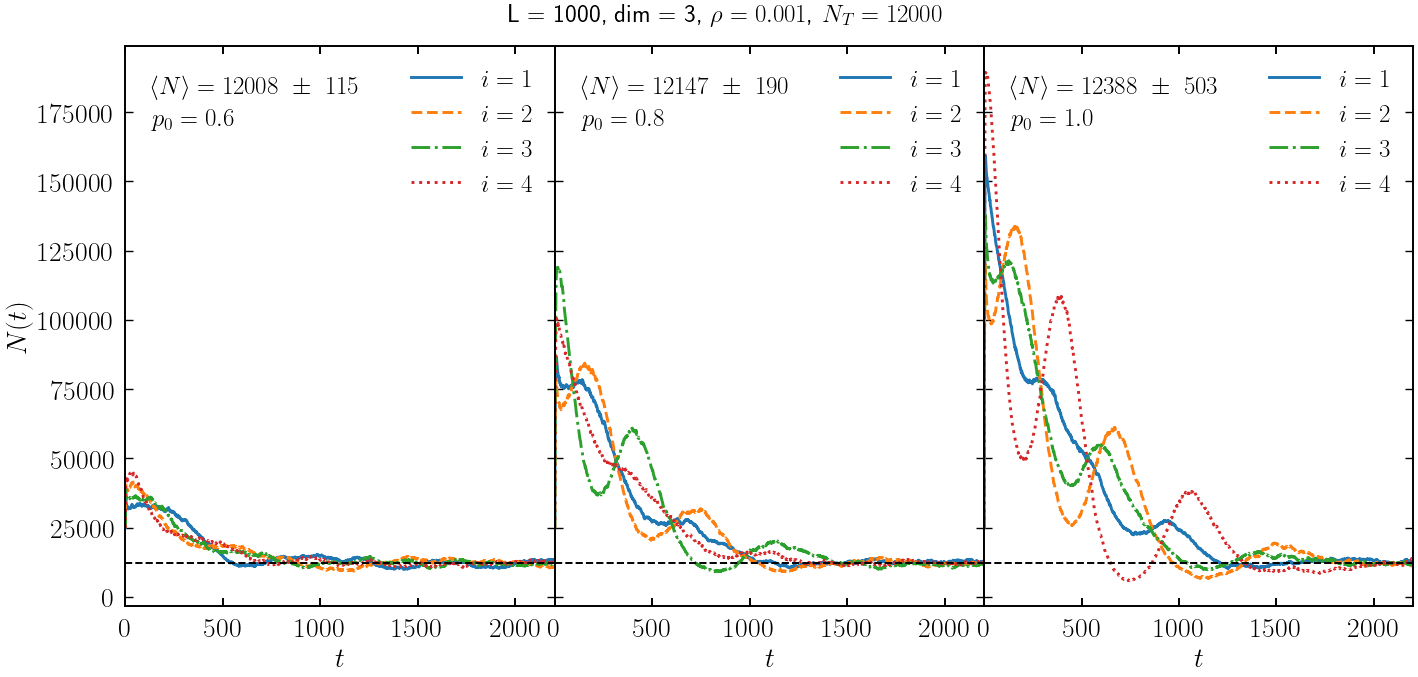

In [16]:
# ---------- seus parâmetros ----------
type_perc = "bond"
num_colors = 4
dim = 3
L = 1000
NT = 12000
k=1.0e-08
rho=1.0e-03
p0_lst = [0.6, 0.8, 1.0]
seed_name = [14574188, 344587444, 198323458]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharex=True, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0, 'hspace': 0}  # cola os subplots
)

results = []
rng = np.random.default_rng(54321)

count = 0
linestyles = ['solid', 'dashed', 'dashdot', "dotted", 'None']
#linestyles = ['solid', 'solid', 'solid', 'solid']
for index, ax in enumerate(axes):
    p0 = p0_lst[index]
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed_name[index])
    
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"N_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.5*thickness)

    ax.set_xlabel("$t$")
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.set_xlim([0, max(data["t"])])
    #ax.set_ylim([0.4, 1.0])

    means_per_curve_Nt = []
    for i in range(1, num_colors+1):
        mi = tail_mean(data[f"N_{i}"], tail_frac=tail_frac)
        if np.isfinite(mi):
            means_per_curve_Nt.append(mi)

    mean_Nt, se_Nt, (lo_Nt, hi_Nt) = bootstrap_mean_scalar(means_per_curve_Nt, prop='Nt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"p0": p0, "mean": mean_Nt, "se": se_Nt, "lo": lo_Nt, "hi": hi_Nt, "n_used": len(means_per_curve_Nt)})
    count += mean_Nt
    ax.legend(fontsize=18)
    
    txt1 = fmt_pm_N(mean_Nt, se_Nt, n_used=len(means_per_curve_Nt), dec=0)  # ajuste dec se quiser
    txt2 = rf"$p_0 = {p0:.1f}$"
    ax.text(0.06, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.06, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)

for ax in axes:
    ax.axhline(y=count/3, xmin=0, xmax=1.0, color='k', ls='--', lw=thickness)  # xmin/xmax em fração do eixo

axes[0].set_ylabel(r"$N(t)$")
# tira rótulos de y dos painéis internos para ficar limpo/colado
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# margens externas (não afetam o espaçamento entre subplots)
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $N_T = {NT}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)

plt.show()

# # ---------- resumo no console ----------
# print("Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
# for r in results:
#     print(f"p0={r['p0']:.1f} | n_curves={r['n_used']} | "
#           f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")

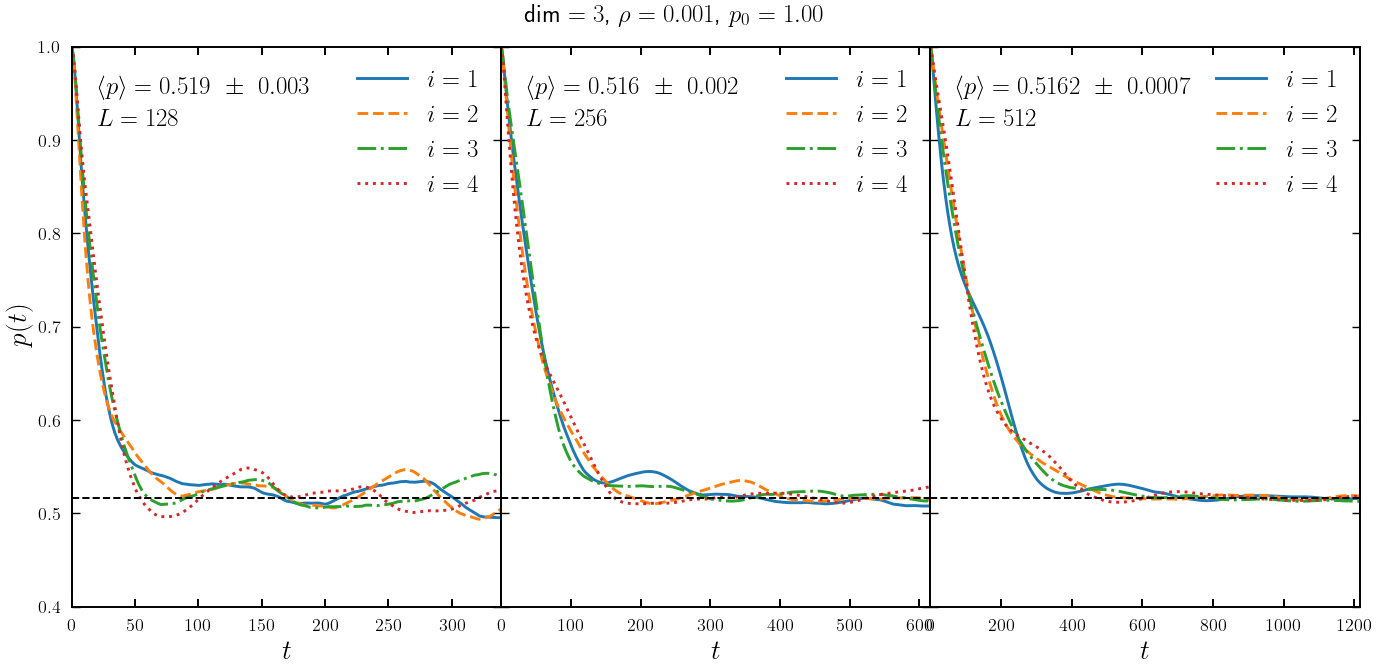

Resumo por tamanho (média de p(t) na cauda + erro bootstrap entre as 4 curvas):
L=128, NT=205, k=1e-05 | n_curves=4 | mean=0.518723 ± 0.002654 (IC95%: 0.512630–0.523603)
L=256, NT=820, k=1e-06 | n_curves=4 | mean=0.516162 ± 0.001510 (IC95%: 0.513293–0.518885)
L=512, NT=3270, k=1e-07 | n_curves=4 | mean=0.516158 ± 0.000699 (IC95%: 0.514887–0.517414)


In [14]:
# ---------- parâmetros (três tamanhos) ----------
type_perc = "bond"
num_colors = 4
dim = 3
L_list  = [128, 256, 512]
NT_list = [205, 820, 3270]
k_list  = [1.0e-05, 1.0e-06, 1.0e-07]
rho = 1.0e-03
p0  = 1.00
seed_list = [1895519391, 1055002752, 869271575]

fontsize_ticks = 13
thickness = 1.4
tail_frac = 0.30
n_boot    = 20000
ci        = 0.95

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0, 'hspace': 0}  # cola os subplots
)

results = []
rng = np.random.default_rng(12345)
count = 0
for ax, L, NT, kk, seed in zip(axes, L_list, NT_list, k_list, seed_list):
    data = data_single_sample(type_perc, num_colors, dim, L, NT, kk, rho, p0, seed)

    # curvas p_i(t)
    linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"p_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.5*thickness)

    # eixos
    ax.set_xlabel("$t$")
    ax.set_xlim(0, max(data["t"]))
    ax.set_ylim(0.4, 1.0)
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks)
    # (opcional) escolha dinâmica do passo no x:
    # ax.xaxis.set_major_locator(MultipleLocator(max(50, int(max(data["t"])/6))))

    # média na cauda por curva + bootstrap entre-curvas
    means_per_curve = [tail_mean(data[f"p_{i}"], tail_frac=tail_frac) for i in range(1, num_colors+1)]
    means_per_curve = [m for m in means_per_curve if np.isfinite(m)]

    mean_pt, se_pt, (lo_pt, hi_pt) = bootstrap_mean_scalar(means_per_curve, prop='pt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"L": L, "NT": NT, "k": kk, "mean": mean_pt, "se": se_pt, "lo": lo_pt, "hi": hi_pt, "n_used": len(means_per_curve)})

    # título/legenda por painel
    ax.legend(fontsize=18)
    #ax.set_title(fr"$L={L}$, $N_T={NT}$, $k={kk:.0e}$"+"\n"+fr"$\bar{{p}}={mean_pt:.3f}\ \pm\ {se_pt:.3f}$", fontsize=12)
    if(count!=2):
        txt1 = fmt_pm(mean_pt, se_pt, n_used=len(means_per_curve), dec=3)  # ajuste dec se quiser
    else:
        txt1 = fmt_pm(mean_pt, se_pt, n_used=len(means_per_curve), dec=4)  # ajuste dec se quiser
    txt2 = rf"$L = {L}$"
    ax.text(0.06, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.06, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    count += 1

axes[0].set_ylabel(r"$p(t)$")
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# linha média global (entre os 3 subplots), se quiser:
global_mean = np.nanmean([r["mean"] for r in results])
for ax in axes:
    ax.axhline(y=global_mean, xmin=0, xmax=1.0, color='k', ls='--', lw=thickness)

fig.suptitle(fr"dim $= {dim}$, $\rho={rho}$, $p_0={p0:.2f}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)
plt.show()

# ---------- resumo no console ----------
print("Resumo por tamanho (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
for r in results:
    print(f"L={r['L']}, NT={r['NT']}, k={r['k']:.0e} | n_curves={r['n_used']} | "
          f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")


In [10]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()

# ver somente um range de colunas
df_clean_3d.loc[:, "rho":"nt_erro"]

,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro
0,0.004336,1.0,1.0,200.0,200.0,0.522865,2.909680e-04,206.367944,0.598805
1,0.004336,1.0,2.0,200.0,200.0,0.523300,3.175227e-04,206.367737,0.605460
2,0.004336,1.0,3.0,200.0,200.0,0.523349,3.034902e-04,205.870979,0.556963
3,0.004336,1.0,4.0,200.0,200.0,0.524933,3.699300e-04,205.639243,0.649715
4,0.008571,1.0,1.0,200.0,200.0,0.525787,2.991207e-04,205.735691,0.553872
...,...,...,...,...,...,...,...,...,...
488,0.228980,1.0,1.0,200.0,17.0,1.000000,4.291845e-08,45.546761,2.796494
489,0.228980,1.0,2.0,200.0,1.0,1.000000,0.000000e+00,29.821942,0.000000
492,0.229590,1.0,1.0,200.0,6.0,1.000000,0.000000e+00,44.040328,3.528385
496,0.229660,1.0,1.0,200.0,8.0,1.000000,0.000000e+00,37.047205,5.623302


In [11]:
np.sort(df_clean_3d["rho"].unique())

array([0.0043356, 0.0085712, 0.012807 , 0.017042 , 0.021278 , 0.025514 ,
       0.029749 , 0.033985 , 0.03822  , 0.042456 , 0.046692 , 0.050927 ,
       0.055163 , 0.059398 , 0.063634 , 0.067869 , 0.072105 , 0.076341 ,
       0.080576 , 0.084812 , 0.089047 , 0.093283 , 0.097519 , 0.10175  ,
       0.10599  , 0.11023  , 0.11446  , 0.1187   , 0.12293  , 0.12717  ,
       0.1314   , 0.13564  , 0.13987  , 0.14411  , 0.14835  , 0.15258  ,
       0.15682  , 0.16105  , 0.16529  , 0.16952  , 0.17376  , 0.17799  ,
       0.18223  , 0.18647  , 0.19     , 0.1907   , 0.19102  , 0.19203  ,
       0.19305  , 0.19407  , 0.19494  , 0.19508  , 0.1961   , 0.19712  ,
       0.19814  , 0.19915  , 0.19917  , 0.20017  , 0.20119  , 0.2022   ,
       0.20322  , 0.20341  , 0.20424  , 0.20525  , 0.20627  , 0.20729  ,
       0.20764  , 0.20831  , 0.20932  , 0.21034  , 0.21061  , 0.21122  ,
       0.21136  , 0.21184  , 0.21188  , 0.21237  , 0.21245  , 0.21306  ,
       0.21339  , 0.21367  , 0.21429  , 0.21441  , 

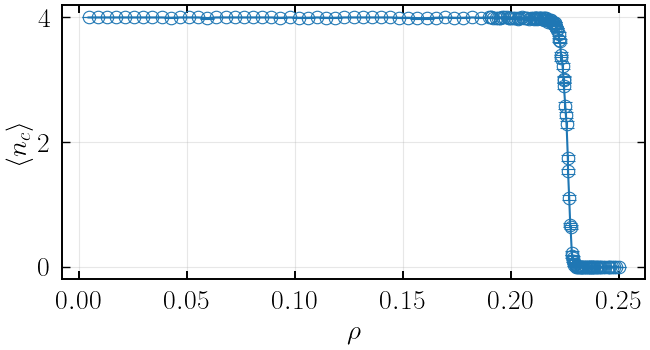

,rho,N,nc_mean,nc_sem
0,0.004336,200,4.0,0.0
1,0.008571,200,4.0,0.0
2,0.012807,200,4.0,0.0
3,0.017042,200,4.0,0.0
4,0.021278,200,4.0,0.0
...,...,...,...,...
161,0.245930,200,0.0,0.0
162,0.246950,200,0.0,0.0
163,0.247970,200,0.0,0.0
164,0.248980,200,0.0,0.0


In [12]:
def mean_nc_by_rho(df, num_colors=4, p0_filter=None):
    """
    Calcula média do número de cores percoladas por seed (n_c) para cada rho.
    Usa as colunas: 'rho', 'order', 'num_samples', 'num_sample_perc'.
    Se p0_filter não for None, filtra df por esse p0 antes de agregar.
    Retorna DataFrame com: rho, N, nc_mean, nc_sem.
    """
    d = df.copy()
    # garantir numérico
    for c in ["rho","order","num_samples","num_sample_perc","p0"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    if p0_filter is not None and "p0" in d.columns:
        d = d[d["p0"].round(2).eq(round(float(p0_filter), 2))]

    rows = []
    for rho, grp in d.groupby("rho"):
        # N (seeds totais) — deve ser o mesmo para todas as ordens, pega o máximo por segurança
        N = int(np.nanmax(grp["num_samples"])) if len(grp) else 0
        if N <= 0:
            rows.append({"rho": rho, "N": 0, "nc_mean": np.nan, "nc_sem": np.nan})
            continue

        # vetor M_k: seeds com >= k cores percoladas
        M = np.zeros(num_colors+2, dtype=float)  # 1..C e M[C+1]=0
        for _, r in grp.iterrows():
            k = int(r["order"])
            if 1 <= k <= num_colors:
                M[k] = float(r["num_sample_perc"])
        # garante não-negativo
        M = np.clip(M, 0, N)

        # média pelo "tail-sum"
        nc_mean = np.sum(M[1:num_colors+1]) / N

        # contas exatas por k: x_k = M_k - M_{k+1}
        X = np.zeros(num_colors+1, dtype=float)  # 1..C
        for k in range(1, num_colors+1):
            X[k] = max(M[k] - M[k+1], 0.0)
        p = X[1:num_colors+1] / N
        ks = np.arange(1, num_colors+1, dtype=float)

        var_nc = np.sum((ks - nc_mean)**2 * p)
        nc_sem = np.sqrt(var_nc / N) if N > 0 else np.nan

        rows.append({"rho": rho, "N": N, "nc_mean": nc_mean, "nc_sem": nc_sem})

    out = pd.DataFrame(rows).sort_values("rho").reset_index(drop=True)
    return out

# ---------- exemplo de uso com seu df ----------
# df_all_3d: carregue com na_values para converter "Null" em NaN
# df_all_3d = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep="\t", na_values=["Null"])

# Se você já tem df_all_3d e quer considerar só casos válidos de pt/nt:
# (Para n_c NÃO é estritamente necessário filtrar por pt/nt; usamos contagens 'num_sample_perc')
# Aqui uso o df completo:
res = mean_nc_by_rho(df_all_3d, num_colors=4, p0_filter=1.0)  # use p0_filter=None para agregar sobre todos p0

# ---------- plot ----------
plt.figure(figsize=(7,4))
plt.errorbar(res["rho"], res["nc_mean"], yerr=res["nc_sem"], fmt="o-", capsize=5)
plt.xlabel(r"$\rho$")
plt.ylabel(r"$\langle n_c \rangle$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Também pode inspecionar a tabela:
display(res)